In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [17]:
df = pd.read_csv("train.csv")
print(df.shape)
display(df.head())

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])
print("Duplicate rows:", df.duplicated().sum())

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Duplicate rows: 0


In [8]:
df_clean = df.copy()
df_clean["MSSubClass"] = df_clean["MSSubClass"].astype("object")

cat_cols = df_clean.select_dtypes(include=["object"]).columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns

df_clean[cat_cols] = df_clean[cat_cols].fillna("None")
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

print("Remaining missing values:", df_clean.isna().sum().sum())

Remaining missing values: 0


C:\Users\huwaei\AppData\Local\Temp\ipykernel_11024\4003125396.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=["object"]).columns


In [9]:
Q1 = df_clean["SalePrice"].quantile(0.25)
Q3 = df_clean["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df_no_outliers = df_clean[(df_clean["SalePrice"] >= lower) & (df_clean["SalePrice"] <= upper)]
print("Outliers removed:", df_clean.shape[0] - df_no_outliers.shape[0])
print("New shape:", df_no_outliers.shape)

Outliers removed: 61
New shape: (1399, 81)


In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

features = ["SalePrice", "GrLivArea", "TotalBsmtSF", "GarageArea", "1stFlrSF"]
X = df_no_outliers[features].copy()

# MinMax
minmax = MinMaxScaler()
X_minmax = pd.DataFrame(minmax.fit_transform(X), columns=features)
display(X_minmax.head())

# Z-score
scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X), columns=features)
display(X_std.head())

# PCA
pca = PCA(n_components=len(features))
pcs = pca.fit_transform(X_std)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

,SalePrice,GrLivArea,TotalBsmtSF,GarageArea,1stFlrSF
0,0.568994,0.259231,0.140098,0.386460,0.119780
1,0.480498,0.174830,0.206547,0.324401,0.212942
2,0.618158,0.273549,0.150573,0.428773,0.134465
3,0.344477,0.260550,0.123732,0.452750,0.143873
4,0.705015,0.351168,0.187398,0.589563,0.186095


,SalePrice,GrLivArea,TotalBsmtSF,GarageArea,1stFlrSF
0,0.646235,0.490416,-0.413565,0.436731,-0.773389
1,0.190222,-0.442178,0.584257,0.005793,0.363259
2,0.899575,0.648623,-0.256272,0.730553,-0.594213
3,-0.510685,0.504987,-0.659333,0.897052,-0.479429
4,1.347142,1.506277,0.296708,1.847074,0.035703


Explained variance ratio: [0.62797121 0.1563979  0.11838786 0.06200901 0.03523402]
Cumulative: [0.62797121 0.78436911 0.90275697 0.96476598 1.        ]


In [11]:
pc_cols = [f"PC{i+1}" for i in range(len(features))]
df_pca = pd.DataFrame(pcs, columns=pc_cols)
df_pca.head()

,PC1,PC2,PC3,PC4,PC5
0,0.142670,-1.210948,0.031548,0.293039,-0.210737
1,0.342093,0.622768,0.296176,0.328489,0.067531
2,0.605858,-1.295223,0.132587,0.291438,-0.187714
3,-0.188962,-0.965351,0.356414,-0.896248,-0.295271
4,2.184729,-1.585655,0.372880,-0.179994,-0.354788


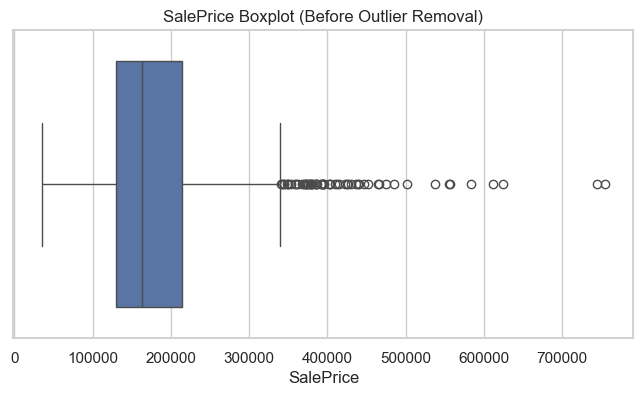

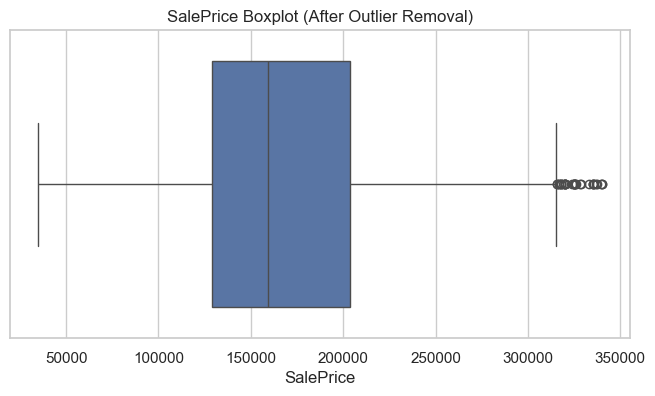

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["SalePrice"])
plt.title("SalePrice Boxplot (Before Outlier Removal)")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df_no_outliers["SalePrice"])
plt.title("SalePrice Boxplot (After Outlier Removal)")
plt.show()

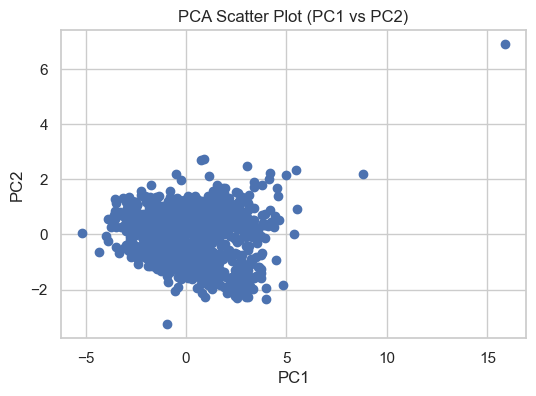

In [13]:
pc_cols = [f"PC{i+1}" for i in range(len(features))]
df_pca = pd.DataFrame(pcs, columns=pc_cols)

plt.figure(figsize=(6,4))
plt.scatter(df_pca["PC1"], df_pca["PC2"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot (PC1 vs PC2)")
plt.show()